In [109]:
!pip install tensorflow_addons

# clone Impala repository, refresh folder to see the Imapala repository
# runtime -> change runtime -> choose a gpu/tpu
!git clone https://github.com/hubtru/Impala

fatal: destination path 'Impala' already exists and is not an empty directory.


In [110]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras as k
from keras import layers
from sklearn.model_selection import train_test_split
import cv2
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [111]:
# ============================== gpu info ==============================
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
print("GPUs: ", tf.config.list_physical_devices("GPU"))

Num GPUs Available:  0
GPUs:  []


In [112]:
# ============================== variables ==============================
# architecture
image_size = 256
filters = 256
depth = 4
columns = 4
widths = 4
kernel_size = 5
patch_size = 16
num_classes = 3

in_channel = 3
img_rows, img_cols = image_size, image_size
input_shape = (img_rows, img_cols, in_channel)

learning_rate = 0.001
weight_decay = 0.0001
batch_size = 8
epochs = 20

In [113]:
# ============================== paths ==============================
# needed for generate_data
modality = "chip"
exp_name = f"impala3d_v3_hexa_reg"
model_name = f"{exp_name}_{modality}"
model_save_path = f"{model_name}.h5"

# dataset
csv_path = "/content/Impala/dataset/labels_reg_sample.csv"
chip_path = f"/content/Impala/dataset/{modality}"

In [114]:
# ============================== load/prepare dataset ==============================
df = pd.read_csv(csv_path)

# RANDOM DATASET: we switch to toolbased
# shuffle, need same state for tool/spec/chips/multi
np.random.seed(55)
df = df.iloc[np.random.permutation(len(df))]
# train/test/val : 70/15/15
train_df, test_df = train_test_split(df, test_size=0.3)
test_df, val_df = train_test_split(test_df, test_size=0.5)

print(
    "size check train/test/val",
    len(train_df),
    len(test_df),
    len(val_df),
    (len(train_df) + len(test_df) + len(val_df)),
)

train_df["chip"] = train_df.id.map(lambda id: f"{chip_path}/{id}.jpg")
test_df["chip"] = test_df.id.map(lambda id: f"{chip_path}/{id}.jpg")
val_df["chip"] = val_df.id.map(lambda id: f"{chip_path}/{id}.jpg")

size check train/test/val 14 3 3 20


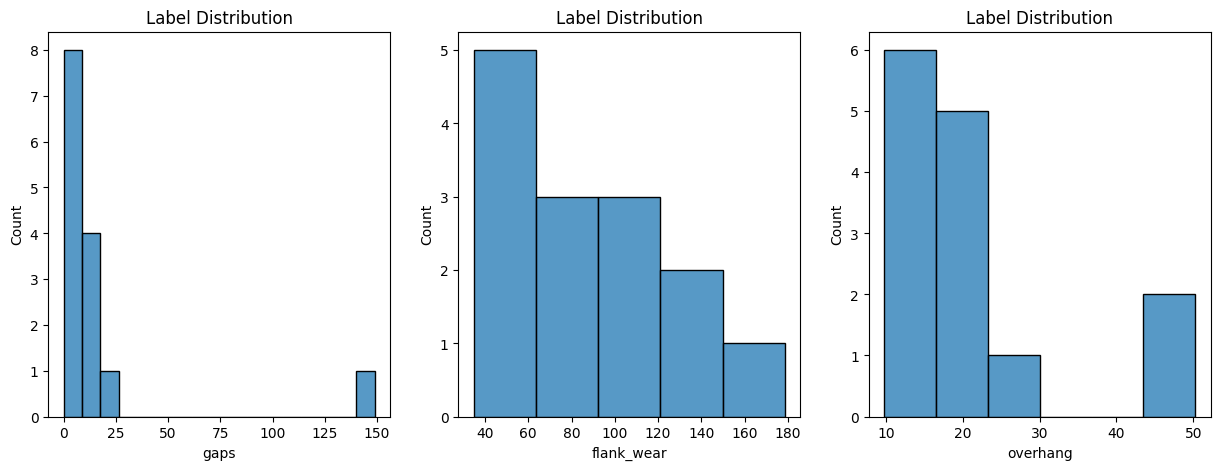

In [115]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
sns.histplot(train_df["gaps"], ax=ax[0])
sns.histplot(train_df["flank_wear"], ax=ax[1])
sns.histplot(train_df["overhang"], ax=ax[2])
ax[0].set_title("Label Distribution")
ax[1].set_title("Label Distribution")
ax[2].set_title("Label Distribution")
plt.show()

In [116]:
print("check if permutation is same on all models")
print("train_head", train_df.head())
print("test_head", test_df.head())
print("val_head", val_df.head())

check if permutation is same on all models
train_head          id   gaps  flank_wear  overhang  \
14   T8R3B4   6.88       40.92     14.54   
10   T6R9B3  12.94       95.63     16.65   
0    T1R2B1   7.67       34.89     48.61   
3   T2R13B4   0.00      122.59     25.55   
1    T1R7B4  13.89       85.41     50.25   

                                        chip  
14   /content/Impala/dataset/chip/T8R3B4.jpg  
10   /content/Impala/dataset/chip/T6R9B3.jpg  
0    /content/Impala/dataset/chip/T1R2B1.jpg  
3   /content/Impala/dataset/chip/T2R13B4.jpg  
1    /content/Impala/dataset/chip/T1R7B4.jpg  
test_head          id   gaps  flank_wear  overhang  \
16   T9R7B4   0.00       94.62     17.05   
18  T10R3B4   0.00       44.26      7.10   
9   T5R12B1  21.79      334.39     16.14   

                                        chip  
16   /content/Impala/dataset/chip/T9R7B4.jpg  
18  /content/Impala/dataset/chip/T10R3B4.jpg  
9   /content/Impala/dataset/chip/T5R12B1.jpg  
val_head          id   g

In [117]:
def read_tools(file_paths, img_rows, img_cols, channels):
    """
    Reads the spectogram files from disk and normalizes the pixel values
      @params:
        file_paths - Array of file paths to read from
        img_rows - The image height.
        img_cols - The image width.
        as_grey - Read the image as Greyscale or RGB.
        channels - Number of channels.
      @returns:
        The created and compiled model (Model)
    """
    images = []

    for file_path in file_paths:
        img = cv2.imread(file_path)
        res = cv2.resize(img, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC)
        images.append(res)

    images = np.asarray(images, dtype=np.float32)

    # normalize
    images = images / np.max(images)

    # reshape to match Keras expectaions
    images = images.reshape(images.shape[0], img_rows, img_cols, channels)

    return images

In [118]:
x_train_chip = read_tools(train_df.chip.values, img_rows, img_cols, in_channel)
x_test_chip = read_tools(test_df.chip.values, img_rows, img_cols, in_channel)
x_val_chip = read_tools(val_df.chip.values, img_rows, img_cols, in_channel)

In [119]:
x_train_chip.shape

(14, 256, 256, 3)

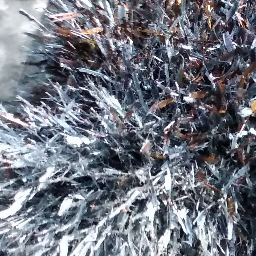

In [120]:
pil_img = tf.keras.utils.array_to_img(x_train_chip[0])
pil_img

In [121]:
labels_train = train_df[["gaps", "flank_wear", "overhang"]]
labels_test = test_df[["gaps", "flank_wear", "overhang"]]
labels_val = val_df[["gaps", "flank_wear", "overhang"]]

In [122]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_chip, labels_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_chip, labels_test))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_chip, labels_val))

In [123]:
# ============================== augment ==============================
auto = tf.data.AUTOTUNE

data_augmentation = k.Sequential(
    [
        k.layers.RandomBrightness(factor=(-0.2, 0.2), value_range=(0, 1)),
        k.layers.RandomContrast(factor=0.2),
        k.layers.GaussianNoise(stddev=0.2),
    ],
    name="data_augmentation",
)

In [124]:
def generate_datasets(images, is_train=False, shuffle=False):
    dataset = images
    if shuffle:
        dataset = dataset.shuffle(batch_size * 10)
    dataset = dataset.batch(batch_size)
    if is_train:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x), y), num_parallel_calls=auto
        )
    return dataset.prefetch(auto)

In [125]:
train_ds = generate_datasets(train_dataset, is_train=True, shuffle=True)
val_ds = generate_datasets(val_dataset)
test_ds = generate_datasets(test_dataset)

In [126]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float64, name=None))>

In [127]:
# ============================== build model ==============================
def activation_block(x):
    x = layers.Activation("gelu")(x)
    return layers.BatchNormalization()(x)


def conv_stem(x, filters: int, patch_size: int):
    x = layers.Conv2D(filters, kernel_size=patch_size, strides=patch_size)(x)
    return activation_block(x)


def conv_mixer_block(
    x, pe_block, column, level, depth, width, r_arr, filters: int, kernel_size: int
):
    if column == 0:
        # Depthwise convolution.
        x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x)
        x = layers.Add()([activation_block(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_block(x)

        if width != 0:
            x0 = fusion_block_double(r_arr[width - 1][column][level], x0)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)
        return x, r_arr
    elif column != 0:
        if level == 0:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], pe_block)
        elif level <= depth - 2:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], x)
            if width != 0:
                x = fusion_block_double(r_arr[width - 1][column - 1][level + 1], x)
        else:
            x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x0)
        x = layers.Add()([activation_block(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_block(x)

        x = fusion_block_double(r_arr[width][column - 1][level], x)
        if width != 0:
            x = fusion_block_double(r_arr[width - 1][column][level], x)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)

        return x, r_arr

    return x, r_arr


def fusion_block_double(x, y):
    return layers.Add()([x, y])


def reverasable_output_array(x, r_arr, width, column, level):
    r_arr[width][column][level] = x
    return r_arr


def get_conv_mixer_256_8(
    image_size=image_size,
    filters=filters,
    depth=depth,
    columns=columns,
    width=widths,
    kernel_size=kernel_size,
    patch_size=patch_size,
    num_classes=num_classes,
):
    r_arr = [
        [[None for _ in range(depth)] for _ in range(columns)] for _ in range(width)
    ]

    inputs = k.Input(input_shape)
    # x = layers.Rescaling(scale=1.0 / 255)(inputs)         # already rescaled

    # Extract patch embeddings.
    x = conv_stem(inputs, filters, patch_size)
    pe_block = x

    # ConvMixer blocks.
    for w in range(width):
        for column in range(columns):
            for level in range(depth):
                x, r_arr = conv_mixer_block(
                    x, pe_block, column, level, depth, w, r_arr, filters, kernel_size
                )

    # Classification block.
    x = layers.GlobalAvgPool2D()(x)
    outputs = layers.Dense(num_classes, activation="linear")(x)

    return k.Model(inputs, outputs)

In [128]:
# ============================== run experiment ==============================
def run_experiment(model):
    optimizer = tfa.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer, loss="mse", metrics=[tf.keras.metrics.MeanSquaredError()]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=2,
    )

    _, accuracy = model.evaluate(test_ds)
    print(f"Test error: {round(accuracy, 2)}")

    return history, model

In [129]:
model = get_conv_mixer_256_8()
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d_195 (Conv2D)         (None, 16, 16, 256)          196864    ['input_4[0][0]']             
                                                                                                  
 activation_387 (Activation  (None, 16, 16, 256)          0         ['conv2d_195[0][0]']          
 )                                                                                                
                                                                                                  
 batch_normalization_387 (B  (None, 16, 16, 256)          1024      ['activation_387[0][0]']

In [130]:
history, model = run_experiment(model)

Epoch 1/20
2/2 - 86s - loss: 4431.9604 - mean_squared_error: 4431.9604 - val_loss: 5223.5518 - val_mean_squared_error: 5223.5518 - 86s/epoch - 43s/step
Epoch 2/20
2/2 - 8s - loss: 3750.4666 - mean_squared_error: 3750.4666 - val_loss: 4620.4053 - val_mean_squared_error: 4620.4053 - 8s/epoch - 4s/step
Epoch 3/20
2/2 - 5s - loss: 3400.3147 - mean_squared_error: 3400.3147 - val_loss: 3962.0964 - val_mean_squared_error: 3962.0964 - 5s/epoch - 3s/step
Epoch 4/20
2/2 - 5s - loss: 3236.6394 - mean_squared_error: 3236.6394 - val_loss: 3941.1077 - val_mean_squared_error: 3941.1077 - 5s/epoch - 3s/step
Epoch 5/20
2/2 - 5s - loss: 2800.8318 - mean_squared_error: 2800.8318 - val_loss: 4590.1768 - val_mean_squared_error: 4590.1768 - 5s/epoch - 3s/step
Epoch 6/20
2/2 - 5s - loss: 2670.0190 - mean_squared_error: 2670.0190 - val_loss: 4741.0317 - val_mean_squared_error: 4741.0317 - 5s/epoch - 3s/step
Epoch 7/20
2/2 - 7s - loss: 2755.3503 - mean_squared_error: 2755.3503 - val_loss: 4741.9331 - val_mean_

In [131]:
model.save(model_save_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
pred = model.predict(test_ds)

In [132]:
# ============================== generate data ==============================
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interp
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import PredictionErrorDisplay
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras as k

In [ ]:
multi_pred = pred
gaps_pred, flank_wear_pred, overhang_pred = multi_pred.T

multi_true = labels_test.to_numpy()
gaps_true, flank_wear_true, overhang_true = multi_true.T

In [133]:
labels_list = [
    "gaps",
    "flank_wear",
    "overhang",
    "multi",
]
pred_list = [
    gaps_pred,
    flank_wear_pred,
    overhang_pred,
    multi_pred,
]
true_list = [
    gaps_true,
    flank_wear_true,
    overhang_true,
    multi_true,
]

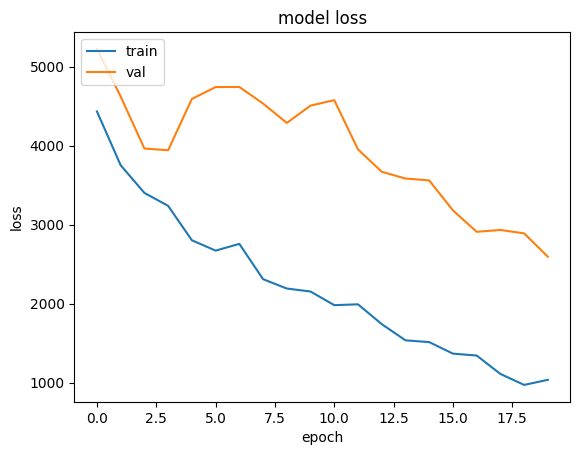

In [134]:
# loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

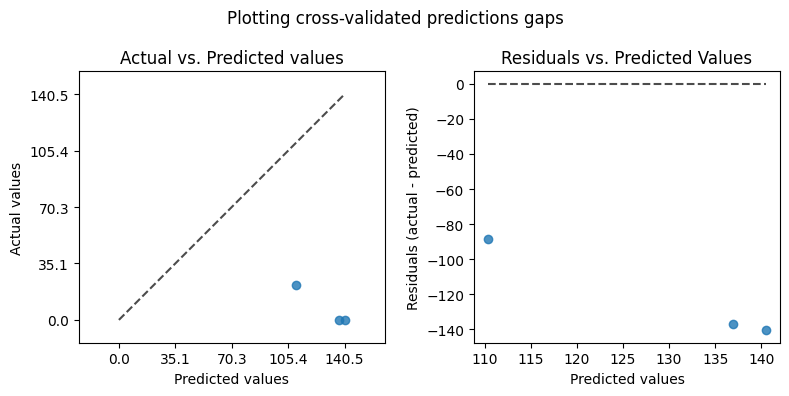

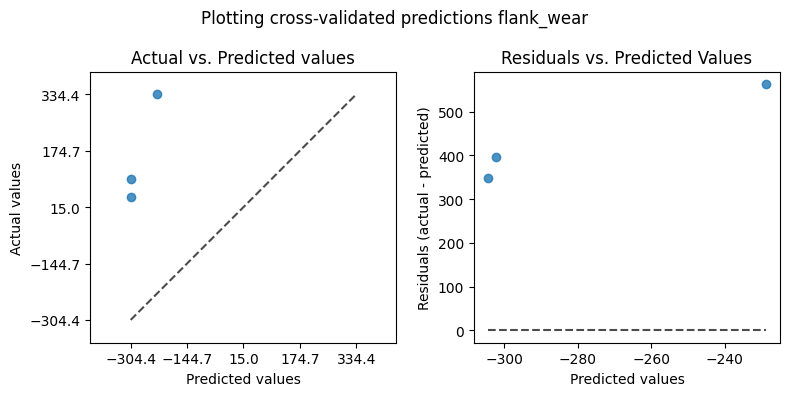

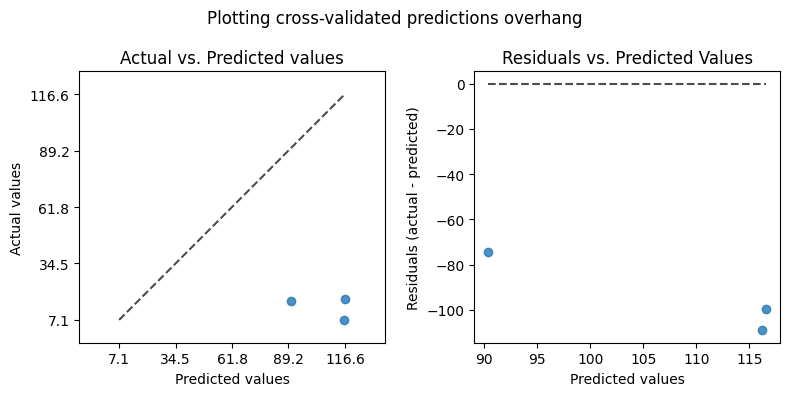

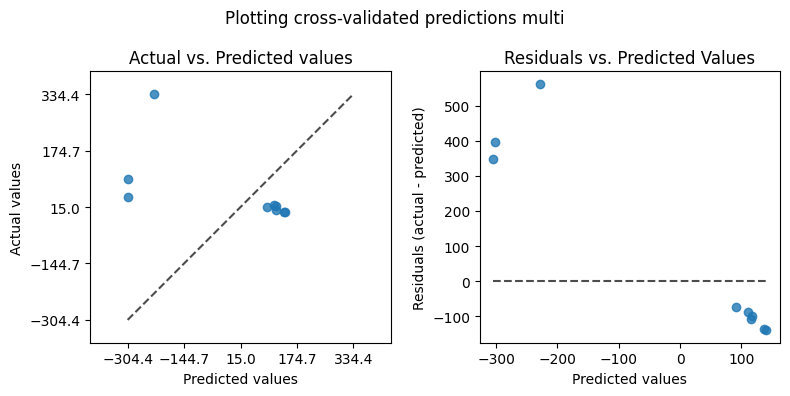

In [135]:
for label, y_pred, y_true in zip(labels_list, pred_list, true_list):
    # https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_predict.html#sphx-glr-auto-examples-model-selection-plot-cv-predict-py
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
    PredictionErrorDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        subsample=100,
        ax=axs[0],
        random_state=0,
    )
    axs[0].set_title("Actual vs. Predicted values")
    PredictionErrorDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        kind="residual_vs_predicted",
        subsample=100,
        ax=axs[1],
        random_state=0,
    )
    axs[1].set_title("Residuals vs. Predicted Values")
    fig.suptitle("Plotting cross-validated predictions " + label)
    plt.tight_layout()
    plt.show()

In [ ]:
def min_shift(list1, list2):
    list1 = np.array(list1)
    list2 = np.array(list2)
    if list1.ndim == 2:
        for i in range(len(list1)):
            if np.min([list1, list2]) > 0:
                continue
            min = np.min([list1[i], list2[i]])
            list1[i] -= min
            list2[i] -= min
        return list1, list2

    min = np.min([list1, list2])
    list1 = list1 - min
    list2 = list1 - min

    return list1, list2

In [136]:
for label, y_pred, y_true in zip(labels_list, pred_list, true_list):
    print(f"===== {label} results =====")
    print("MAE: ", metrics.mean_absolute_error(y_true, y_pred))
    print("MSE: ", metrics.mean_squared_error(y_true, y_pred))
    print("RMSE: ", metrics.mean_squared_error(y_true, y_pred, squared=False))
    print("r2_score: ", metrics.r2_score(y_true, y_pred))
    try:
        print("MSLE: ", metrics.mean_squared_log_error(y_true, y_pred))
    except ValueError as err:
        y_true_shift, y_pred_shift = min_shift(y_true, y_pred)
        print(
            "MSLE_min_shifted: ",
            metrics.mean_squared_log_error(y_true_shift, y_pred_shift),
        )
    print("MAPE: ", metrics.mean_absolute_percentage_error(y_true, y_pred))

===== gaps results =====
MAE:  122.01841766357423
MSE:  15450.299479602043
RMSE:  124.29923362435524
r2_score:  -145.43164972292612
MSLE:  17.10640762688082
MAPE:  4.165745817556091e+17
===== flank_wear results =====
MAE:  436.2371608479818
MSE:  198742.35624035005
RMSE:  445.80528960561924
r2_score:  -11.404066079932694
MSLE_min_shifted:  0.2879464027501957
MAPE:  4.585491003995415
===== overhang results =====
MAE:  94.29299957275391
MSE:  9107.420816209697
RMSE:  95.43280786086981
r2_score:  -450.4777972720091
MSLE:  4.484315492982151
MAPE:  8.601726013910678
===== multi results =====
MAE:  217.51619269476998
MSE:  74433.35884538727
RMSE:  221.84577703028143
r2_score:  -202.43783769162266
MSLE_min_shifted:  12.320078455951972
MAPE:  1.3885819391853637e+17
